In [1]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import xgboost as xgb
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #scaling gets a slightly lower r2 but much less error
from sklearn.datasets import make_regression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
from src.cleaning_and_helpers import plot_test_preds

In [3]:
# setup plot dimensions
#plt.rcParams['figure.figsize'] = [10, 5]

Import X and y from data prep steps

In [4]:
X = np.load('../pollenGeolocation_saved/X.npy')
y = np.load('../pollenGeolocation_saved/y.npy')

In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1298)

# Create scaler for X and y
sc_X = StandardScaler()
sc_y = StandardScaler()

# Scale training data
X_train = sc_X.fit_transform(X_train)
y_train = sc_y.fit_transform(y_train)  

# Scale test data using training parameters
X_test = sc_X.transform(X_test)
y_test = sc_y.transform(y_test)  
#y_test = np.array(y_test)


# Linear regression  
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.MultiTaskLasso.html

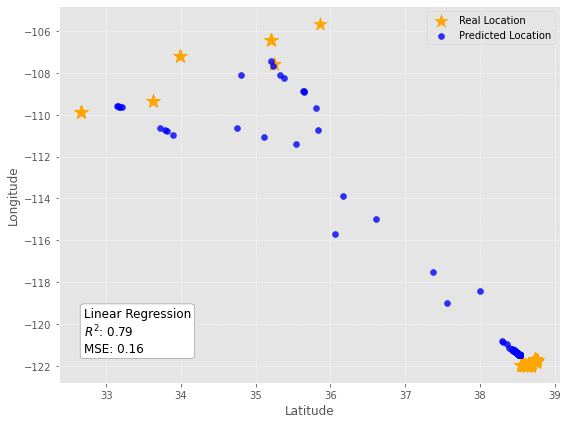

In [6]:

MTLReg = linear_model.MultiTaskLasso(alpha=0.1)
MTLReg.fit(X_train, y_train)
preds_LR = MTLReg.predict(X_test)


LR_rsq = r2_score(y_test,preds_LR)
LR_mse = mean_squared_error(y_test,preds_LR)

plot_test_preds(y_test, preds_LR, sc_y, "Linear Regression")

# SVR Support Vector Regression multioutput regressor
https://medium.com/pursuitnotes/support-vector-regression-in-6-steps-with-python-c4569acd062d  
https://scikit-learn.org/stable/modules/svm.html#regression
https://datascience.stackexchange.com/questions/82743/valueerror-y-should-be-a-1d-array-got-an-array-of-shape-285-30-instead  
https://www.section.io/engineering-education/support-vector-regression-in-python/

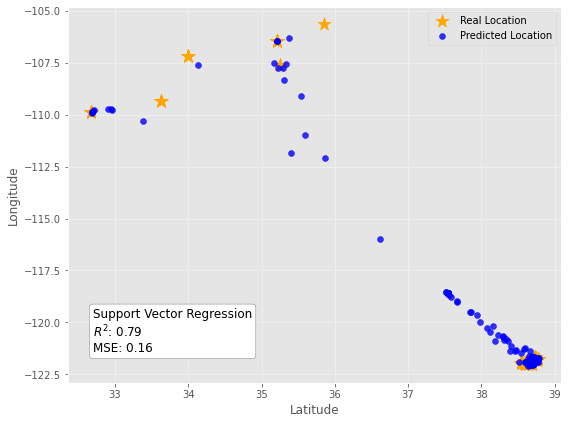

In [7]:
# Create the SVR regressor
svr = SVR(epsilon=0.01)

# Create the Multioutput Regressor
mor = MultiOutputRegressor(svr)

# Train the regressor
mor = mor.fit(X_train, y_train)

# Generate predictions for testing data
preds_SVR = mor.predict(X_test)

SVR_rsq = r2_score(y_test,preds_SVR)
SVR_mse = mean_squared_error(y_test,preds_SVR)

plot_test_preds(y_test, preds_SVR, sc_y, "Support Vector Regression")

# k-Nearest Neighbors for Multioutput Regression
https://machinelearningmastery.com/multi-output-regression-models-with-python/

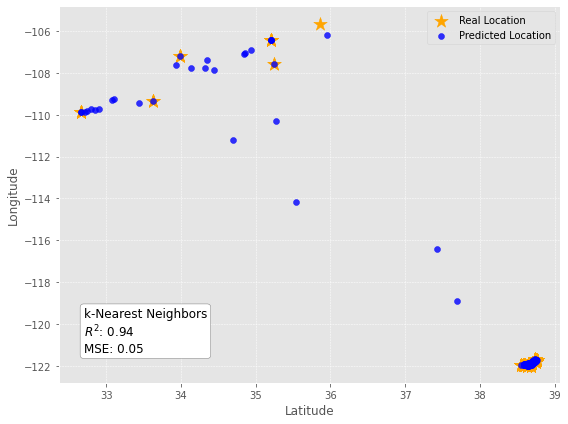

In [8]:
# fit model
KNR = KNeighborsRegressor(algorithm='auto', weights='distance') #slightly better when weighted by distance
KNR = KNR.fit(X_train, y_train)

preds_knr = KNR.predict(X_test)

KNR_rsq = r2_score(y_test,preds_knr)
KNR_mse = mean_squared_error(y_test,preds_knr)

plot_test_preds(y_test, preds_knr, sc_y, "k-Nearest Neighbors")

# Decision Tree for multioutput regression  


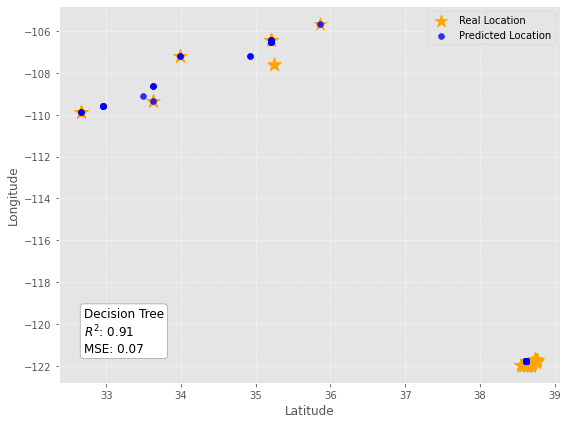

In [9]:
# fit model
DTR = DecisionTreeRegressor(max_depth=5)
DTR = DTR.fit(X_train, y_train)

preds_DTR = DTR.predict(X_test)

DTR_rsq = r2_score(y_test,preds_DTR)
DTR_mse = mean_squared_error(y_test,preds_DTR)

plot_test_preds(y_test, preds_DTR, sc_y, "Decision Tree")

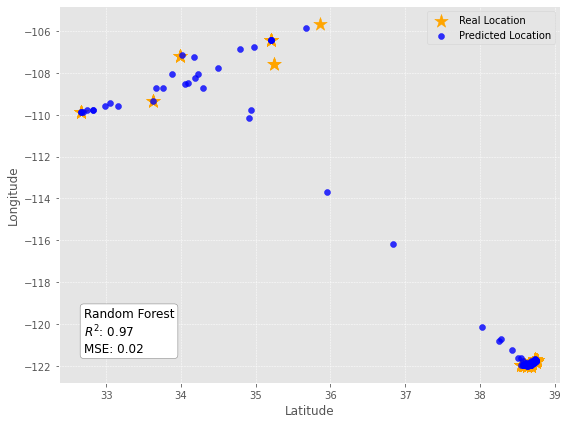

In [12]:
#Random forest

# Using tuned model
rf =RandomForestRegressor(n_estimators = 400,
                          min_samples_split = 2, 
                          min_samples_leaf = 1, 
                          max_features = 'sqrt', 
                          max_depth = None, 
                          bootstrap = False) 
rf = rf.fit(X_train,y_train)

pred_train = rf.predict(X_train)
preds_RF = rf.predict(X_test)

RF_rsq = r2_score(y_test,preds_RF)
RF_mse = mean_squared_error(y_test,preds_RF)

plot_test_preds(y_test, preds_RF, sc_y, "Random Forest")

https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74

In [14]:
RF_tuning = False
if RF_tuning == True:
    from sklearn.model_selection import RandomizedSearchCV
    # Number of trees in random forest
    n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
    # Number of features to consider at every split
    max_features = ['auto', 'sqrt']
    # Maximum number of levels in tree
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    # Minimum number of samples required to split a node
    min_samples_split = [2, 5, 10]
    # Minimum number of samples required at each leaf node
    min_samples_leaf = [1, 2, 4]
    # Method of selecting samples for training each tree
    bootstrap = [True, False]
    # Create the random grid
    random_grid = {'n_estimators': n_estimators,
                'max_features': max_features,
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'bootstrap': bootstrap}
    print(random_grid)

    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)
    # Fit the random search model
    rf_random.fit(X_train, y_train)

    rf_random.best_params_



XGBoost

In [15]:
data_dmatrix = xgb.DMatrix(data=X,label=y)

# set up xgboost regressor
xg_reg = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1,
                max_depth = 5, alpha = 10, n_estimators = 10)

# fit the regressor
xg_reg.fit(X_train,y_train)

preds_xg = xg_reg.predict(X_test)

# compute rmse
XG_rsq = r2_score(y_test,preds_xg)
XG_mse = mean_squared_error(y_test,preds_xg)

print(XG_rsq)
print(XG_mse)





0.5243163674654989
0.3573572508406695


In [ ]:
#create dictionary to store hyperparameters

params = {"objective":"reg:squarederror",'colsample_bytree': 0.3,'learning_rate': 0.1,
                'max_depth': 5, 'alpha': 10}

#cross validation
cv_results = xgb.cv(dtrain=data_dmatrix, params=params, nfold=10,
                    num_boost_round=50,early_stopping_rounds=10,metrics="rmse", as_pandas=True, seed=123)

In [ ]:
#cv_results contains train and test RMSE metrics for each boosting round.

cv_results.head()

In [19]:
from xgboost import XGBRegressor
# Create the base XGBoost regressor
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Wrap with MultiOutputRegressor for multioutput regression
multi_xgb = MultiOutputRegressor(xgb)

# Train the model
multi_xgb.fit(X_train, y_train)

# Generate predictions
y_pred_xg = multi_xgb.predict(X_test)


In [20]:
# R² score
print("R² score:", r2_score(y_test, y_pred_xg))

# Mean Squared Error
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xg))

R² score: 0.9045348270752229
Mean Squared Error: 0.07118052892418239


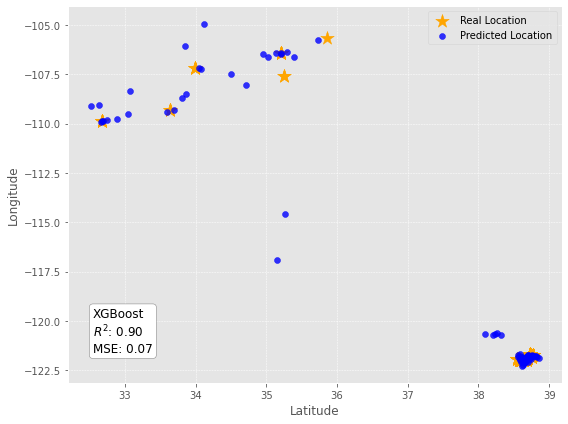

In [22]:
plot_test_preds(y_test, y_pred_xg, sc_y, "XGBoost")

In [ ]:
# hyperparam tuning for xgboost
# Example hyperparameter grid for XGBRegressor
param_grid = {
    'estimator__n_estimators': [50, 100, 200],
    'estimator__max_depth': [3, 5, 7],
    'estimator__learning_rate': [0.01, 0.1, 0.2],
    'estimator__subsample': [0.8, 1.0],
    'estimator__colsample_bytree': [0.8, 1.0],
    'estimator__reg_alpha': [0, 0.1, 1],  # L1 regularization
    'estimator__reg_lambda': [0.1, 1, 10],  # L2 regularization
}
# Set up RandomizedSearchCV
xgb_random = RandomizedSearchCV(
    estimator=multi_xgb,
    param_distributions=param_grid,
    n_iter=100,  # Number of parameter settings sampled
    cv=3,        # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1    # Use all available cores
)
# Fit the RandomizedSearchCV
xgb_random.fit(X_train, y_train)

# Get the best parameters
print("Best parameters found: ", xgb_random.best_params_)


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Get predictions using the best estimator
best_xgb = xgb_random.best_estimator_
y_pred = best_xgb.predict(X_test)

# Evaluate performance
print("R² score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))


In [ ]:
y_test_split = np.hsplit(y_test, 2)
y_pred_split = np.hsplit(y_pred, 2)


plt.scatter(y_test_split[0], y_test_split[1], marker='*', alpha=0.1, s=100)
plt.scatter(y_pred_split[0], y_pred_split[1], alpha=0.1)

In [ ]:
method = ['Linear Regression', 'SVR Support Vector Regression' , 'k-Nearest Neighbors', 'Decision Tree']
rsquared = [LR_rsq, SVR_rsq, KNR_rsq, DTR_rsq]
MSE = [LR_mse, SVR_mse, KNR_mse, DTR_mse]

df = pd.DataFrame({'Method' : method,
              'rsquared' : rsquared,
              'MSE' : MSE})
df

lets see the top 10 features, looks like the most important is the unknown Asteraceae sPA (cultivated sunflower?) followed by Tanacetum corymbosum, a small white daisy
https://www.nbshare.io/notebook/312837011/Decision-Tree-Regression-With-Hyper-Parameter-Tuning-In-Python/

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as acc
names = np.load('X_cols.npy', allow_pickle = True)
reg= ExtraTreesRegressor()
reg.fit(X_train,y_train)
importance = reg.feature_importances_
#print(np.column_stack((names, importance)))
feat_importances = pd.Series(reg.feature_importances_, index=names)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
#lets look at RBCL:Asteraceae_unknown_sp._A


In [ ]:
import folium
from math import atan 
from folium.plugins import MarkerCluster

from geopy.distance import geodesic

 

#need to change outputs from two arrays with n rows to n arrays with 2 columns
y_test_new = np.column_stack((y_inverse[0],y_inverse[1])) 
preds_new = np.column_stack((preds_inverse[0],preds_inverse[1])) 
y_and_preds = np.concatenate((y_test_new,preds_new),axis=1)

def get_dists(real_predicted_coords):
    dists_list = []
    for line in real_predicted_coords:
        x = geodesic([line[0],line[1]], [line[2],line[3]]).mi
        dists_list.append(x)
    return dists_list
    
dists = get_dists(y_and_preds)

mapit = folium.Map( location=[36.1699, -115.1398], zoom_start=6)
folium.TileLayer('Stamen Terrain').add_to(mapit)
    
for coord in preds_new:
    folium.Marker( location=[ coord[0], coord[1] ], icon=folium.Icon(color="gray",icon="question-circle-o", prefix='fa'), radius=8 ).add_to( mapit )
    marker_cluster1 = MarkerCluster().add_to(mapit)
for coord in preds_new:
    folium.Marker(location=[ coord[0], coord[1] ], icon=folium.Icon(color="gray",icon="question-circle-o", prefix='fa')).add_to(marker_cluster1)

for coord in y_test_new:
    folium.Marker( location=[ coord[0], coord[1] ], icon=folium.Icon(color="green",icon="leaf", prefix='fa'), radius=8 ).add_to( mapit )    
marker_cluster = MarkerCluster().add_to(mapit)
for coord in y_test_new:
    folium.Marker(location=[ coord[0], coord[1] ], icon=folium.Icon(color="green",icon="leaf", prefix='fa'), radius=8).add_to(marker_cluster)

def assign_colors(dist_list):
    color_pick = []
    for lens in dists:
        if lens <= 5:
            color_pick.append('Green')
        elif 5 < lens <= 15:
            color_pick.append('Orange')
        elif lens > 15:
            color_pick.append('Red')
    return color_pick

my_colors = assign_colors(dists)    

marker_len = 0
for coord in y_and_preds:
    folium.PolyLine(locations = ([ coord[0], coord[1] ], [coord[2], coord[3]]), color=my_colors[marker_len]).add_to(mapit)
    marker_len += 1
    

    ### also figure out how to change heatmap of stacked points in the marker cluster!
    #and how to get rid of marker shadows

In [ ]:
mapit

In [ ]:
plt.hist(dists, bins=np.arange(0, len(dists)+1, 5))

In [ ]:
print(([ y_and_preds[0], y_and_preds[1] ], [y_and_preds[2], y_and_preds[3]]))